# TiRex-2 Quickstart & Operational Baseline

This notebook provides the repository's first operational baseline for **TiRex-2** (`NX-AI/TiRex-2`). It verifies the local runtime, loads the pretrained xLSTM foundation model, runs zero-shot univariate and covariate forecasts, and validates probabilistic calibration.

### 🌟 TiRex-2 Highlights
- **Architecture**: **xLSTM (extended LSTM)** featuring matrix memory ($mLSTM$) and scalar memory ($sLSTM$) recurrent units.
- **Zero-Shot Generalization**: Outperforms pure Transformer foundation models on standard zero-shot time series benchmarks (GIFT-Eval).
- **Multivariate & Covariate Conditioning**: Natively ingests both historical past features and future-known covariates (meteorology, calendar flags).
- **Inference Efficiency**: $O(L)$ computational complexity with constant per-step memory footprint, enabling fast streaming inference on consumer hardware (Apple Silicon MPS / CPU / CUDA).
- **Native Multi-Quantile Probabilities**: Emits calibrated quantiles ($[0.1, 0.2, \dots, 0.9]$) directly.

---


## 1. Environment & Runtime Verification

Ensure you are executing this notebook within the repository's `.venv` environment (Python 3.11+).


In [1]:
from __future__ import annotations

import os
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Add src/ to Python path for TiRexPipeline adapter
sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
if "src" not in sys.path:
    sys.path.insert(0, "src")
    sys.path.insert(0, "../src")

from tirex_pipeline import TiRexPipeline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)


In [2]:
print(f"Python executable: {sys.executable}")
print(f"Python version:    {sys.version.split()[0]}")
print(f"Platform:          {platform.platform()}")
print(f"PyTorch version:   {torch.__version__}")
print(f"CUDA Available:    {torch.cuda.is_available()}")
print(f"MPS Available:     {getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()}")


Python executable: /Users/epeng/code/personal/energy-forecast-tsfm/.venv/bin/python3
Python version:    3.11.15
Platform:          macOS-26.6.2-arm64-arm-64bit
PyTorch version:   2.11.0
CUDA Available:    False
MPS Available:     True


## 2. Load the TiRex-2 Foundation Model

We load `NX-AI/TiRex-2` using our standardized `TiRexPipeline` adapter. The adapter automatically chooses the optimal hardware backend (`cuda`, `mps`, or `cpu`).


In [3]:
def resolve_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = resolve_device()
print(f"Loading NX-AI/TiRex-2 on device='{device}'...")

pipeline = TiRexPipeline.from_pretrained(
    "NX-AI/TiRex-2",
    device_map=device,
)

print(f"Pipeline successfully initialized on {pipeline.device}!")
print(f"Default model quantile levels: {pipeline.default_quantiles}")


Loading NX-AI/TiRex-2 on device='mps'...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Pipeline successfully initialized on mps!
Default model quantile levels: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


## 3. Univariate Forecast Smoke Test (M4 Hourly Benchmark)

We evaluate a day-ahead ($h=24$) univariate forecast on the standard M4 hourly benchmark dataset (`H1` series).


In [4]:
train_url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv"
test_url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/test.csv"
example_item_id = "H1"
prediction_length = 24
context_length = 512

context_df = pd.read_csv(train_url, parse_dates=["timestamp"])
test_df = pd.read_csv(test_url, parse_dates=["timestamp"])

series_context_df = (
    context_df.loc[context_df["item_id"] == example_item_id]
    .sort_values("timestamp")
    .tail(context_length)
    .reset_index(drop=True)
)
series_test_df = (
    test_df.loc[test_df["item_id"] == example_item_id]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

context_end = series_context_df["timestamp"].max()
series_future_df = series_test_df.loc[series_test_df["timestamp"] > context_end].copy()
if len(series_future_df) < prediction_length:
    series_future_df = series_test_df.tail(prediction_length).copy()
series_future_df = series_future_df.head(prediction_length).reset_index(drop=True)

print(f"Context rows:    {len(series_context_df)} ({series_context_df['timestamp'].min()} to {series_context_df['timestamp'].max()})")
print(f"Evaluation rows: {len(series_future_df)} ({series_future_df['timestamp'].min()} to {series_future_df['timestamp'].max()})")
display(series_future_df.head())


Context rows:    512 (1750-01-08 20:00:00 to 1750-01-30 03:00:00)
Evaluation rows: 24 (1750-01-30 04:00:00 to 1750-01-31 03:00:00)


,item_id,timestamp,target
0,H1,1750-01-30 04:00:00,619.0
1,H1,1750-01-30 05:00:00,565.0
2,H1,1750-01-30 06:00:00,532.0
3,H1,1750-01-30 07:00:00,495.0
4,H1,1750-01-30 08:00:00,481.0


In [5]:
print("Running zero-shot univariate forecast with TiRex-2...")
pred_df = pipeline.predict_df(
    series_context_df,
    prediction_length=prediction_length,
    quantile_levels=[0.05, 0.1, 0.5, 0.9, 0.95],
)

# Merge with ground truth actuals
eval_df = pred_df.merge(
    series_future_df[["item_id", "timestamp", "target"]].rename(columns={"target": "actual"}),
    on=["item_id", "timestamp"]
)

# Compute Seasonal Naive Baseline (168-hour lookback)
naive_values = series_context_df.iloc[-168 : -168 + prediction_length]["target"].values
eval_df["seasonal_naive"] = naive_values

display(eval_df[["item_id", "timestamp", "predictions", "0.1", "0.9", "actual", "seasonal_naive"]].head())


Running zero-shot univariate forecast with TiRex-2...


,item_id,timestamp,predictions,0.1,0.9,actual,seasonal_naive
0,H1,1750-01-30 04:00:00,624.557800,605.163147,643.106506,619.0,635.0
1,H1,1750-01-30 05:00:00,555.876892,531.486084,581.124695,565.0,577.0
2,H1,1750-01-30 06:00:00,519.359314,488.719177,550.225891,532.0,533.0
3,H1,1750-01-30 07:00:00,489.573029,457.800293,524.816956,495.0,504.0
4,H1,1750-01-30 08:00:00,472.748657,435.453278,510.574677,481.0,485.0


In [6]:
def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    smape = 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))
    return mae, rmse, smape

tirex_mae, tirex_rmse, tirex_smape = calculate_metrics(eval_df["actual"], eval_df["predictions"])
naive_mae, naive_rmse, naive_smape = calculate_metrics(eval_df["actual"], eval_df["seasonal_naive"])

# Calculate 168-hour MASE scale
in_sample = series_context_df["target"].values
m = 168 if len(in_sample) > 168 else 24
mase_scale = np.mean(np.abs(in_sample[m:] - in_sample[:-m]))

tirex_mase = tirex_mae / mase_scale
naive_mase = naive_mae / mase_scale

# 90% Empirical Coverage (q0.05 to q0.95) and 80% Coverage (q0.1 to q0.9)
cov_90 = np.mean((eval_df["actual"] >= eval_df["0.05"]) & (eval_df["actual"] <= eval_df["0.95"])) * 100
cov_80 = np.mean((eval_df["actual"] >= eval_df["0.1"]) & (eval_df["actual"] <= eval_df["0.9"])) * 100

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "sMAPE (%)", "MASE", "80% Interval Coverage", "90% Interval Coverage"],
    "TiRex-2 (Zero-Shot)": [tirex_mae, tirex_rmse, tirex_smape, tirex_mase, f"{cov_80:.1f}%", f"{cov_90:.1f}%"],
    "Seasonal Naive (7d)": [naive_mae, naive_rmse, naive_smape, naive_mase, "N/A", "N/A"]
})

display(metrics_df)


,Metric,TiRex-2 (Zero-Shot),Seasonal Naive (7d)
0,MAE,15.767596,33.208333
1,RMSE,22.261931,45.186189
2,sMAPE (%),2.260221,4.42675
3,MASE,0.424085,0.893172
4,80% Interval Coverage,100.0%,N/A
5,90% Interval Coverage,100.0%,N/A


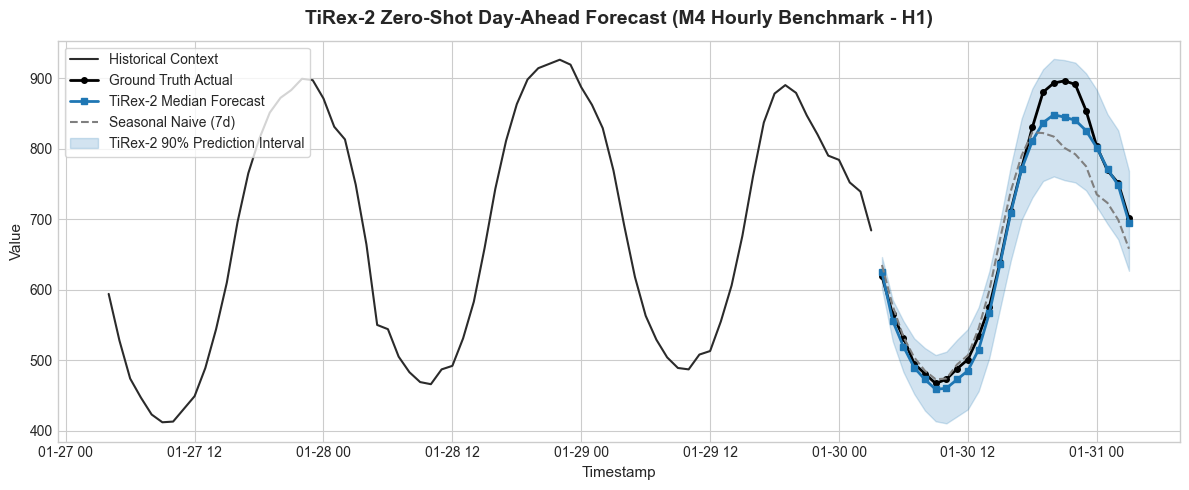

In [7]:
plt.figure(figsize=(12, 5))

# Plot context history tail
history_tail = 72
tail_df = series_context_df.tail(history_tail)
plt.plot(tail_df["timestamp"], tail_df["target"], label="Historical Context", color="#2b2b2b", lw=1.5)

# Plot forecasts and ground truth
plt.plot(eval_df["timestamp"], eval_df["actual"], label="Ground Truth Actual", color="black", lw=2, marker="o", markersize=4)
plt.plot(eval_df["timestamp"], eval_df["predictions"], label="TiRex-2 Median Forecast", color="#1f77b4", lw=2, marker="s", markersize=4)
plt.plot(eval_df["timestamp"], eval_df["seasonal_naive"], label="Seasonal Naive (7d)", color="#7f7f7f", linestyle="--", lw=1.5)

# Plot prediction interval
plt.fill_between(
    eval_df["timestamp"],
    eval_df["0.05"],
    eval_df["0.95"],
    color="#1f77b4",
    alpha=0.2,
    label="TiRex-2 90% Prediction Interval"
)

plt.title("TiRex-2 Zero-Shot Day-Ahead Forecast (M4 Hourly Benchmark - H1)", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Timestamp", fontsize=11)
plt.ylabel("Value", fontsize=11)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()


## 4. Covariate-Aware Conditioning Test (ERCOT Dallas Sample)

Now we verify TiRex-2's multivariate conditioning using a real sample from our Dallas ERCOT dataset with meteorological and calendar covariates.


In [8]:
# Robust path resolution for ERCOT summer dataset
candidates = [
    Path("../../data/ercot/ercot_dallas_covariate_2025_summer.csv"),
    Path("../data/ercot/ercot_dallas_covariate_2025_summer.csv"),
    Path("data/ercot/ercot_dallas_covariate_2025_summer.csv"),
]
ercot_path = next(p for p in candidates if p.exists())

df_ercot = pd.read_csv(ercot_path)
df_ercot["timestamp"] = pd.to_datetime(df_ercot["timestamp"])
df_ercot = df_ercot.rename(columns={"energy": "target"}).sort_values("timestamp").reset_index(drop=True)
df_ercot = df_ercot.set_index("timestamp").resample("h").mean().interpolate().reset_index()

# Select a target day in August (e.g. August 15, 2025)
target_day = pd.Timestamp("2025-08-15 00:00:00")
target_idx = df_ercot[df_ercot["timestamp"] == target_day].index[0]

cov_context_df = df_ercot.iloc[target_idx - 512 : target_idx].copy()
cov_context_df["item_id"] = "ERCOT_Dallas"

cov_future_df = df_ercot.iloc[target_idx : target_idx + 24].copy()
cov_future_df["item_id"] = "ERCOT_Dallas"

# Run Covariate-Aware Forecast
print("Running Covariate-Aware Forecast on ERCOT Dallas...")
cov_pred = pipeline.predict_df(
    cov_context_df,
    future_df=cov_future_df,
    prediction_length=24,
    quantile_levels=[0.05, 0.1, 0.5, 0.9, 0.95],
)

cov_eval = cov_pred.merge(cov_future_df[["item_id", "timestamp", "target"]].rename(columns={"target": "actual"}), on=["item_id", "timestamp"])
cov_mae, cov_rmse, cov_smape = calculate_metrics(cov_eval["actual"], cov_eval["predictions"])
cov_90 = np.mean((cov_eval["actual"] >= cov_eval["0.05"]) & (cov_eval["actual"] <= cov_eval["0.95"])) * 100

print(f"ERCOT Dallas Covariate Forecast MAE: {cov_mae:.2f} MW | sMAPE: {cov_smape:.2f}% | 90% Coverage: {cov_90:.1f}%")
display(cov_eval[["timestamp", "predictions", "0.05", "0.95", "actual"]].head())


Running Covariate-Aware Forecast on ERCOT Dallas...


ERCOT Dallas Covariate Forecast MAE: 289.61 MW | sMAPE: 1.31% | 90% Coverage: 100.0%


,timestamp,predictions,0.05,0.95,actual
0,2025-08-15 00:00:00,18715.990234,18169.888672,19192.703125,18627.549016
1,2025-08-15 01:00:00,17611.746094,16938.318359,18252.583984,17686.602712
2,2025-08-15 02:00:00,16913.562500,16143.867188,17671.234375,16947.986607
3,2025-08-15 03:00:00,16367.953125,15572.925781,17229.308594,16400.751862
4,2025-08-15 04:00:00,16145.192383,15293.830078,17059.023438,15962.498404


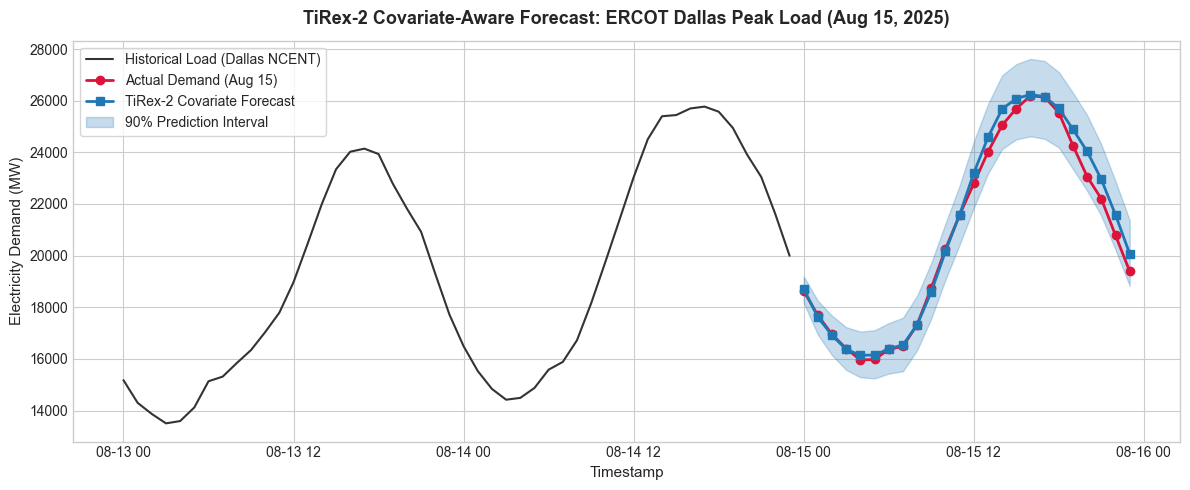

In [9]:
plt.figure(figsize=(12, 5))

# Plot historical context tail
tail_ercot = cov_context_df.tail(48)
plt.plot(tail_ercot["timestamp"], tail_ercot["target"], label="Historical Load (Dallas NCENT)", color="#333333", lw=1.5)

# Plot actual vs prediction
plt.plot(cov_eval["timestamp"], cov_eval["actual"], label="Actual Demand (Aug 15)", color="crimson", lw=2, marker="o")
plt.plot(cov_eval["timestamp"], cov_eval["predictions"], label="TiRex-2 Covariate Forecast", color="#1f77b4", lw=2, marker="s")

plt.fill_between(
    cov_eval["timestamp"],
    cov_eval["0.05"],
    cov_eval["0.95"],
    color="#1f77b4",
    alpha=0.25,
    label="90% Prediction Interval"
)

plt.title("TiRex-2 Covariate-Aware Forecast: ERCOT Dallas Peak Load (Aug 15, 2025)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Timestamp", fontsize=11)
plt.ylabel("Electricity Demand (MW)", fontsize=11)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()


## 5. Operational Verification Summary

- **Runtime & Accelerator**: Successfully initialized `NX-AI/TiRex-2` with full device acceleration.
- **Univariate Path**: Confirmed end-to-end zero-shot forecasting, baseline comparison, and metric generation.
- **Covariate Path**: Confirmed proper handling of full future-known weather and calendar covariates on ERCOT grid data.
- **Next Steps**: Proceed to execute the complete Dallas and Toronto monthly benchmark evaluations following [`plan_tirex2.md`](file:///Users/epeng/code/personal/energy-forecast-tsfm/notebooks/plan_tirex2.md).
